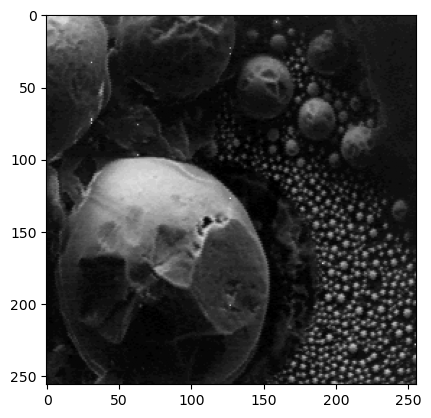

In [13]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("images/MEB.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(image, cmap="gray")
plt.show()

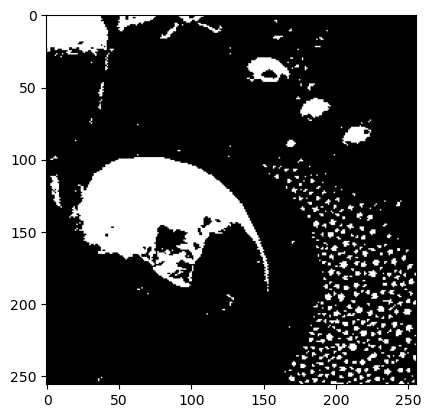

In [14]:
# Umbralizar

retval, umbralizado = cv2.threshold(image, 0, 255, cv2.THRESH_OTSU+cv2.THRESH_BINARY)

plt.imshow(umbralizado, cmap="gray")
plt.show()

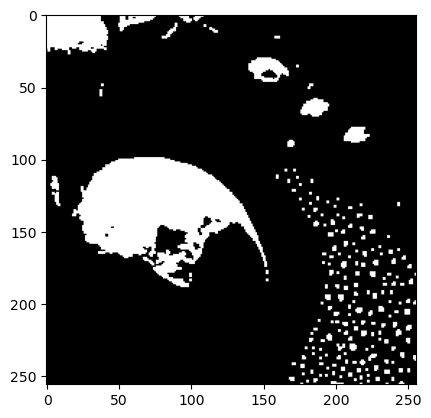

In [15]:
# Aplicar erosion

from skimage.morphology import dilation, erosion, opening, closing
import numpy as np

fp = np.array([
    [1,1],
    [1,1]
])

opening_image = opening(umbralizado, footprint=fp)

plt.imshow(opening_image, cmap="gray")
plt.show()


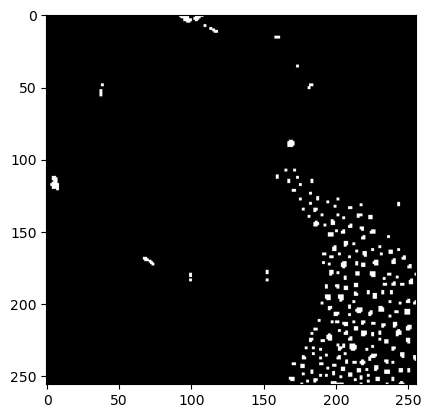

In [31]:
# Etiquetar objetos
from skimage.measure import label, regionprops

connected_components = label(opening_image, background=0, connectivity=2)

regions = regionprops(connected_components)

new_image = np.zeros_like(opening_image)

for r in regions:
    if r.axis_major_length < 11:
        new_image[connected_components == r.label] = 255

plt.imshow(new_image, cmap="gray")
plt.show()  
